1. Czy potrzeba wszystkich cech?

Nie. Zbiór zawiera bardzo dużo cech (561), z czego wiele jest skorelowanych i niesie podobną informację.
Tworzymy Heatmape gdzie to jest widoczne.

2. Czy potrzebna jest obróbka danych?

Tak. Dane wymagają kilku kroków. Wykonałem standaryzacje, PCA, VarianceThreshold

3. Czy wiemy jak obrobić dane?

Tak. VarianceThreshold, potem Standaryzacja, PCA (musi być po standaryzacji), KMeans (klasteryzacja). Potem można użyć kroswalidacji.

4. Czy wiemy co oznacza każda cecha?

Nie. W unsupervised learning nie jest to konieczne, ponieważ model uczy się na danych. Nie wymagana jest zmienna objaśniająca. Potem przy supervised learning potrzebujemy jednak tej zmiennej do obliczenia metryk i stworzenia modelu.

5. Czy potrzebujemy dwóch plików (train/test)?

Tak. Do EDA i klasteryzacji można użyć całego zbioru (tak zrobiłem sobie na początku), ale potem użyłem tylko x_train i stwierdziłem, że to wystarczy żeby uznać, że jest za dużo cech nie potrzebnych. Do trenowania i stratifedKFold używamy tylko x_train, bo nie chcemy mieć wycieku danych (używając testowych).

6. Czy potrzebny jest podział na train/test?

Tak. W części z klasyfikatorami. Używam tam StratifedKFold zamiast standardowego train_test_split, więc działam na całym x_train, a nie tylko np. na 80% z tego x_train.

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.feature_selection import VarianceThreshold
from scipy.stats import mode

In [42]:
# Importuje wszystkie 4 pliki i sprawdzam ich kształt.

X_train = pd.read_csv("samsung_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("samsung_train_labels.txt", header=None).values.ravel()

X_test = pd.read_csv("samsung_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("samsung_test_labels.txt", header=None).values.ravel()

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (7352, 561) (7352,)
Test: (2947, 561) (2947,)


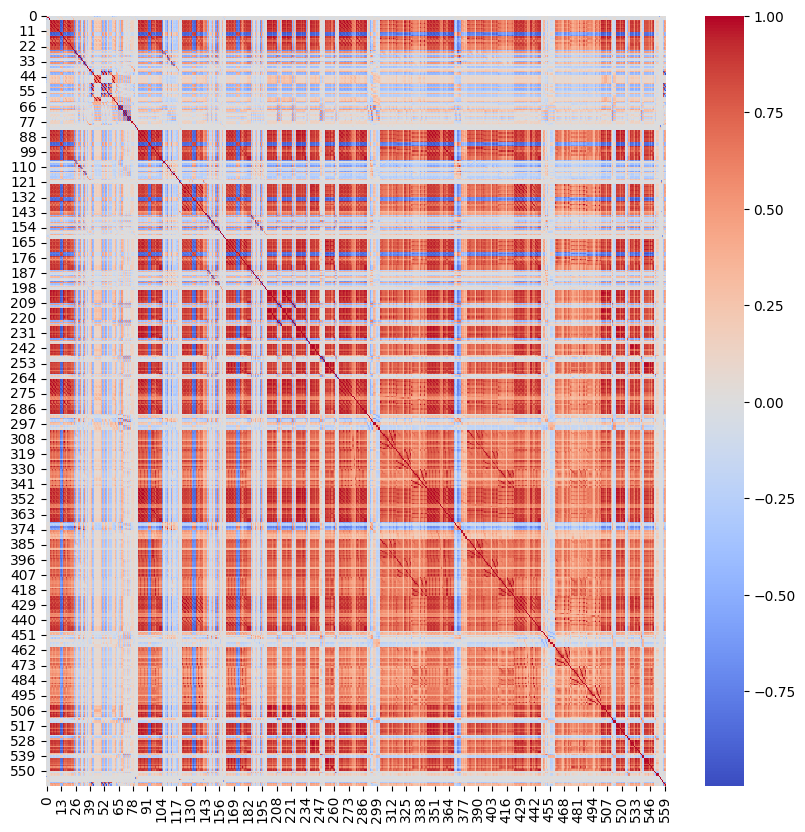

In [43]:
# Heatmapa, która pokazuje korelacje i widać, że jest dużo wartości skorelowanych, więc będzie można część cech ograniczyć. 

plt.figure(figsize=(10,10))
sns.heatmap(X_train.corr(), cmap="coolwarm")
plt.show()

In [44]:
# Wykonuje standaryzacje przed PCA (redukcja wymiarowości). Później PCA.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

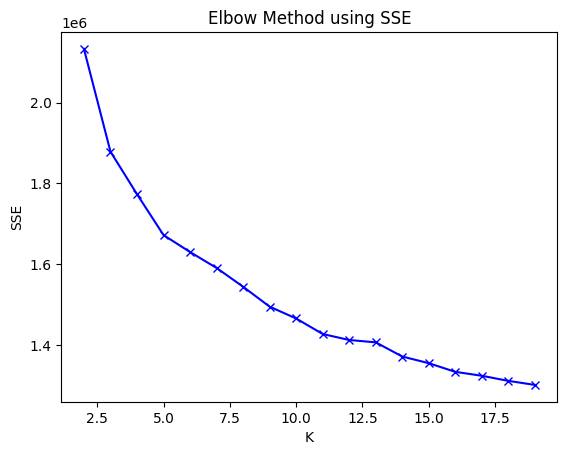

In [46]:
# Sprawdzam ilość potrzebnych klastrów. Za pomocą Elbow method widać, że przedział dobry to ten między 5-6.

kmeans_per_k = [
    KMeans(n_clusters=k, random_state=2).fit(X_pca)
    for k in range(2, 20) # zaczynamy od wartości n_clusters wynoszącej 2, gdyż nie ma sensu dzielenia zbioru dla 1 klastra
]

inertias = [model.inertia_ for model in kmeans_per_k]
plt.plot(range(2, 20), inertias, 'bx-')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method using SSE')
plt.show()

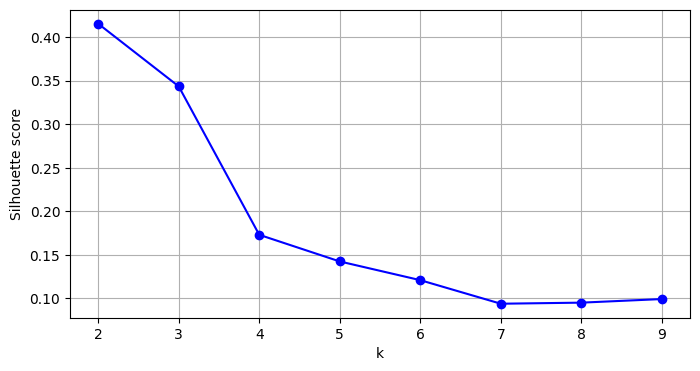

In [47]:
# Druga metoda na sprawdzenie liczby klastrów to Silhouette. Tutaj najlepszą opcją byłby wybór np. 2 klastry.
# W zadaniu jednak mamy 6 czynności (klas), więc dobrze byłoby zrobić podział na 6 klastrów.

k_range = range(2, 10)

kmeans_per_k = [
    KMeans(n_clusters=k, random_state=42).fit(X_pca)
    for k in k_range
]

silhouette_scores = [
    silhouette_score(X_pca, model.labels_)
    for model in kmeans_per_k
]

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, "bo-")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid()
plt.show()

In [48]:
# Wykonuje klasteryzację trzema metodami (kmeans, dbscan, gmm) na zbiorze X_pca (po redukcji wymiarowości i standaryzacji)

kmeans = KMeans(n_clusters=6, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_pca)

dbscan = DBSCAN(eps=1.5, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

gmm = GaussianMixture(n_components=6, random_state=42)
clusters_gmm = gmm.fit_predict(X_pca)

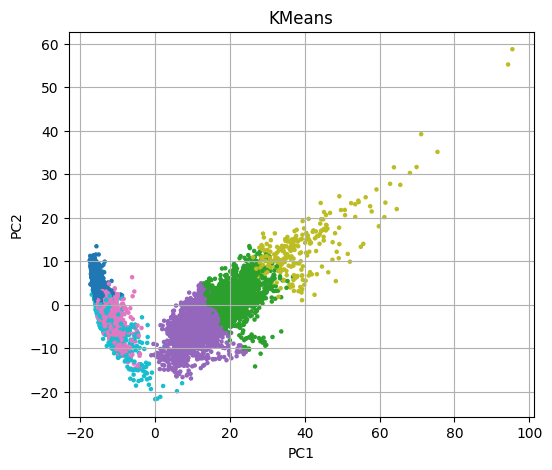

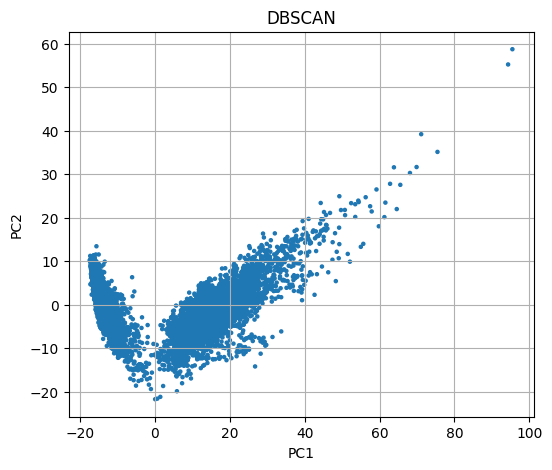

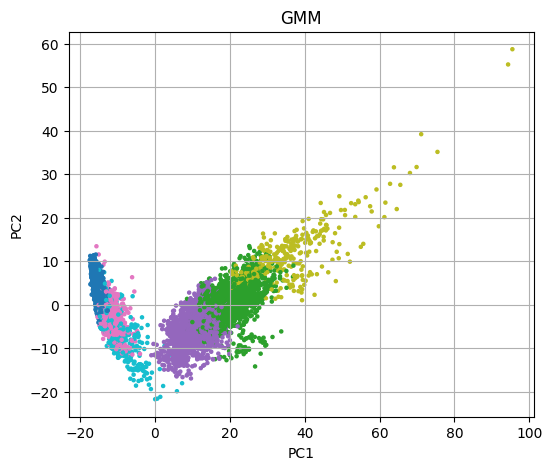

In [49]:
# Tworzę pca_2d potrzebne do wizualizacji, bo redukuje mi wymiary do 2 żeby można byłoby to dobrze pokazać na wykresie.
# Tworzę 3 wykresy do każdej metody clusteringu

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

def plot_clusters(X_2d, labels, title):
    plt.figure(figsize=(6,5))
    plt.scatter(X_2d[:,0], X_2d[:,1], c=labels, s=5, cmap="tab10")
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid()
    plt.show()

plot_clusters(X_2d, clusters_kmeans, "KMeans")
plot_clusters(X_2d, clusters_dbscan, "DBSCAN")
plot_clusters(X_2d, clusters_gmm, "GMM")

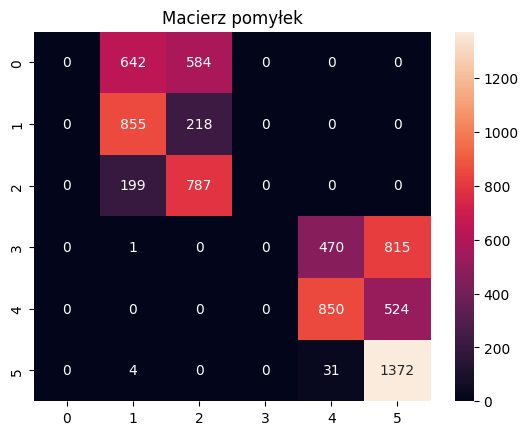

In [51]:
# Funkcja map_clusters potrzebna do stworzenia macierzy pomyłek.

def map_clusters(clusters, y_true):
    mapped = np.zeros_like(clusters)
    for i in np.unique(clusters):
        mask = clusters == i
        mapped[mask] = mode(y_true[mask], keepdims=True)[0]
    return mapped

mapped = map_clusters(clusters_kmeans, y_train)

# Macierz pomyłek wskazuje na wyraźny podział czynności na dwie grupy (jak wskazywał podzial Silhouette).
# Podział to : czynności ruchowe, czynności bez ruchu

cm = confusion_matrix(y_train, mapped)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Macierz pomyłek")
plt.show()

In [52]:
# Transformer potrzebny do KMeans pipeline

class KMeansTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=6):
        self.n_clusters = n_clusters

    def fit(self, X, y=None):
        self.kmeans = KMeans(n_clusters=self.n_clusters, random_state=42)
        self.kmeans.fit(X)
        return self

    def transform(self, X):
        clusters = self.kmeans.predict(X)
        return np.c_[X, clusters]

In [53]:
# Tworzę jeden pipeline do klasyfikatora random forest, a drugi do SVM.
# Zawarłem tam wariancję Threshold, Standaryzacje, PCA, klasteryzacje KMeans, no i wybrany klasyfikator

pipeline_rf = Pipeline([
    ("var", VarianceThreshold(0.01)),
    ("scaler", StandardScaler()),
    ("pca", PCA(0.95)),
    ("kmeans", KMeansTransformer(6)),
    ("rf", RandomForestClassifier(random_state=42))
])

In [54]:
pipeline_svm = Pipeline([
    ("var", VarianceThreshold(0.01)),
    ("scaler", StandardScaler()),
    ("pca", PCA(0.95)),
    ("kmeans", KMeansTransformer(6)),
    ("svm", SVC())
    
])

In [55]:
# Podział za pomocą StratifiedKFold zbioru na 5 części, losowo.
# Liczymy kroswalidację i średni wynik wszystkich części (foldów)
# Widać, że lepiej działa SVM.

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_score = cross_val_score(pipeline_rf, X_train, y_train, cv=skf)
svm_score = cross_val_score(pipeline_svm, X_train, y_train, cv=skf)

print("Random Forest - Kroswalidacja: ", rf_score)
print("Średni wynik wszystkich foldów: ", rf_score.mean())

print("SVM - Kroswalidacja: ", svm_score)
print("Średni wynik wszystkich foldów: ", svm_score.mean())

Random Forest - Kroswalidacja:  [0.9367777  0.93337865 0.93333333 0.93673469 0.91632653]
Średni wynik wszystkich foldów:  0.9313101828086776
SVM - Kroswalidacja:  [0.96668933 0.97348742 0.96734694 0.97210884 0.96394558]
Średni wynik wszystkich foldów:  0.9687156222108151


In [58]:
param_grid = {
    "svm__C": [1, 10, 50],
    "svm__kernel": ["rbf"],
    "svm__gamma": ["scale", 0.01, 0.001]
}

grid = GridSearchCV(
    pipeline_svm,
    param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("CV score:", grid.best_score_)

best_model = grid.best_estimator_

test_score = best_model.score(X_test, y_test)
print("TEST score:", test_score)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
CV score: 0.917849859182286
TEST score: 0.9399389209365456


In [60]:
# Classification_report dla SVM po GridSearchCV

y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.95      0.97      0.96       496
           2       0.91      0.93      0.92       471
           3       0.95      0.89      0.92       420
           4       0.94      0.88      0.91       491
           5       0.89      0.95      0.92       532
           6       1.00      1.00      1.00       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



KMeans bardzo dobrze radzi sobie z rozróżnieniem dwóch głównych typów aktywności: ruchowych (marsz, schody) oraz tych bez ruchu (siedzenie, stanie, leżenie). Widać to w macierzy pomyłek, gdzie podział jest zauważalny.

KMeans, K-Fold i KNN to trzy różne rzeczy w uczeniu maszynowym, które mają inne zastosowania.

KMeans służy do grupowania danych, kiedy nie mamy etykiet. KMeans dzieli dane na określoną liczbę klastrów, która można określić za pomocą metody Elbow albo Silhouette. Grupuje elementy podobne.

K-Fold to nie klasteryzacja, a podział zbioru danych na foldy. Służy to temu, żeby móc pracować na wszystkich danych, a nie tylko na części jak ma to miejsce przy standardowym train_test_split. Tutaj zakładając, że jest 5 foldów, to każdy fold posiada inną część danych testowych, np. FOLD 1 (1 testowym, 2,3,4,5 train) FOLD 3 (1,2 train, 3 test, 4,5 train). Pozwala to na pracę na całym zbiorze.

KNN (K Nearest Neighbors) to klasyfikator używany przy klasyfikacji. Dla nowego punktu patrzy na jego najbliższych „sąsiadów” w danych i na tej podstawie decyduje, do jakiej klasy należy.

DBSCAN widać to na wizualizacji tej metody klasteryzacji, że uznał zbiór jako 1 klaster. Zmieniałem wartości eps, ale nie miało to jakiegoś wpływu. 

SVM wypadł lepiej niż Random Forest, dlatego skorzystałem tam dodatkowo z GridSearchCV. Wynik był lekko słabszy niż przed jego użyciem. Choć nie oznacza to, że wynik był gorszy. Mógł oznaczać, że na zbiorze testowym pokazał realistyczny wynik.